In [1]:
"""import os, shutil, random, pathlib

original_dir = pathlib.Path("./dataset")
base_dir = pathlib.Path("./dataset_split")

splits = ["train", "validation", "test"]

for split in splits:
    for class_name in os.listdir(original_dir):
        os.makedirs(base_dir / split / class_name, exist_ok=True)

for class_name in os.listdir(original_dir):
    images = list((original_dir / class_name).glob("*"))
    random.shuffle(images)
    
    n = len(images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy(img, base_dir / "train" / class_name / img.name)
        
    for img in val_images:
        shutil.copy(img, base_dir / "validation" / class_name / img.name)
        
    for img in test_images:
        shutil.copy(img, base_dir / "test" / class_name / img.name)

print("Dataset jaettu train/validation/test")"""

'import os, shutil, random, pathlib\n\noriginal_dir = pathlib.Path("./dataset")\nbase_dir = pathlib.Path("./dataset_split")\n\nsplits = ["train", "validation", "test"]\n\nfor split in splits:\n    for class_name in os.listdir(original_dir):\n        os.makedirs(base_dir / split / class_name, exist_ok=True)\n\nfor class_name in os.listdir(original_dir):\n    images = list((original_dir / class_name).glob("*"))\n    random.shuffle(images)\n\n    n = len(images)\n    train_end = int(0.7 * n)\n    val_end = int(0.85 * n)\n\n    train_images = images[:train_end]\n    val_images = images[train_end:val_end]\n    test_images = images[val_end:]\n\n    for img in train_images:\n        shutil.copy(img, base_dir / "train" / class_name / img.name)\n\n    for img in val_images:\n        shutil.copy(img, base_dir / "validation" / class_name / img.name)\n\n    for img in test_images:\n        shutil.copy(img, base_dir / "test" / class_name / img.name)\n\nprint("Dataset jaettu train/validation/test")'

In [2]:
import matplotlib.pyplot as plt
import keras
from keras.utils import image_dataset_from_directory
from keras import layers

train_dataset = image_dataset_from_directory(
    "./dataset_split/train",
    image_size=(224, 224),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    "./dataset_split/validation",
    image_size=(224, 224),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    "./dataset_split/test",
    image_size=(224, 224),
    batch_size=32
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Luokat: ", class_names)
print("Luokkien määrä: ", num_classes)


Found 105 files belonging to 3 classes.
Found 21 files belonging to 3 classes.
Found 24 files belonging to 3 classes.
Luokat:  ['autot', 'laivat', 'lentokoneet']
Luokkien määrä:  3


In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x=layers.Rescaling(1.0 / 255)(x)

x = layers.Conv2D(32, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(256, 3, activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(256, 3, activation="relu")(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        76,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,299 (4.03 MB)

 Trainable params: 1,055,299 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model1_cnn.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = model.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.2952 - loss: 1.8211 - val_accuracy: 0.3333 - val_loss: 1.0958
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.2952 - loss: 1.1096 - val_accuracy: 0.3333 - val_loss: 1.1590
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.3333 - loss: 1.0996 - val_accuracy: 0.3333 - val_loss: 1.1138
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - accuracy: 0.4762 - loss: 1.1060 - val_accuracy: 0.3333 - val_loss: 1.0856
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.3238 - loss: 1.1609 - val_accuracy: 0.5238 - val_loss: 1.0923
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.5048 - loss: 1.0793 - val_accuracy: 0.4762 - val_loss: 1.0251
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.4286 - loss: 1.2172 - val_accuracy: 0.3333 - val_loss: 1.2039
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.3619 - loss: 1.1696 - val_accuracy: 0.3333 - val_loss:

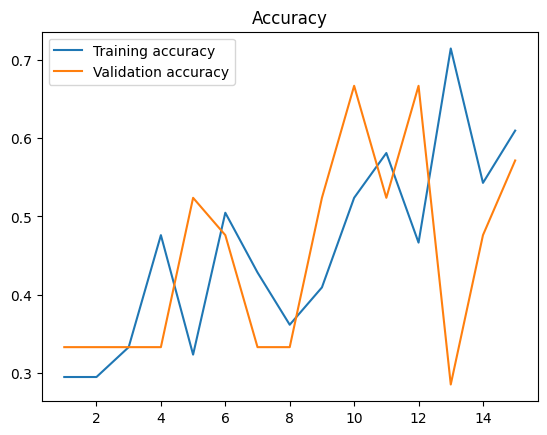

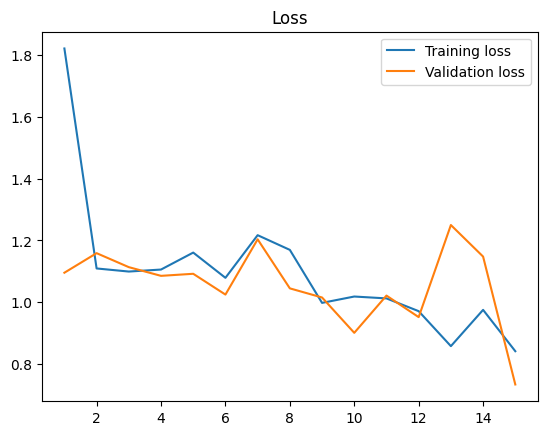

In [7]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.title("Loss")
plt.show()

In [8]:
test_model = keras.models.load_model("model1_cnn.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)

print(f"Test accuracy: {test_acc:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6250 - loss: 0.8505
Test accuracy: 0.625
